# Image Composition

This notebook combines the generated chart with a background image to create a final post.

In [2]:
from PIL import Image
from pathlib import Path

# Base paths
DATA_DIR = Path("..")
FIGURES_DIR = DATA_DIR / "outputs" / "figures"
FINAL_POSTS_DIR = DATA_DIR / "outputs" / "final_posts"

# Instagram 4:5 vertical post dimensions
INSTAGRAM_SIZE = (1080, 1350)

# Define a safe zone (bounding box) where figures must stay
# This prevents overlap with text/branding on the background
# Format: (left, top, right, bottom) in pixels

SAFE_ZONE = {
    'left': 30,       
    'top': 250,       
    'right': 1050,    
    'bottom': 1270    
}

# Define the background and figures to process
BACKGROUND_FILE = FIGURES_DIR / "background.png"
FIGURES_TO_PROCESS = [
    "polutka_lab_goals_vs_xg_post.png",
    "team_age_distribution.png",
    "team_goals_vs_xg_comparison.png",
    "team_xg_performance_difference.png"
]

try:
    # Ensure output directory exists
    FINAL_POSTS_DIR.mkdir(parents=True, exist_ok=True)
    
    # Load background once
    background_template = Image.open(BACKGROUND_FILE)
    
    # Resize background to Instagram 4:5 dimensions if needed
    if background_template.size != INSTAGRAM_SIZE:
        background_template = background_template.resize(INSTAGRAM_SIZE, Image.Resampling.LANCZOS)
        print(f"Background resized to Instagram 4:5 format: {INSTAGRAM_SIZE[0]}x{INSTAGRAM_SIZE[1]}")
    
    bg_width, bg_height = background_template.size
    
    # Calculate safe zone dimensions
    safe_width = SAFE_ZONE['right'] - SAFE_ZONE['left']
    safe_height = SAFE_ZONE['bottom'] - SAFE_ZONE['top']
    
    print(f"Safe zone for figures: {safe_width}x{safe_height} pixels")
    print(f"Position: ({SAFE_ZONE['left']}, {SAFE_ZONE['top']}) to ({SAFE_ZONE['right']}, {SAFE_ZONE['bottom']})\n")
    
    # Process each figure
    for figure_name in FIGURES_TO_PROCESS:
        try:
            # Load a fresh copy of the background for each figure
            background = background_template.copy()
            
            # Load the chart/figure
            chart_path = FIGURES_DIR / figure_name
            chart = Image.open(chart_path)
            
            # Convert to RGBA if not already (to handle transparency)
            if chart.mode != 'RGBA':
                chart = chart.convert('RGBA')
            
            # Stretch the figure to fill the entire safe zone (no aspect ratio preservation)
            chart_resized = chart.resize((safe_width, safe_height), Image.Resampling.LANCZOS)
            
            # Position at the top-left corner of the safe zone
            position_x = SAFE_ZONE['left']
            position_y = SAFE_ZONE['top']
            
            # Paste the chart onto the background
            background.paste(chart_resized, (position_x, position_y), chart_resized)
            
            # Save the final image
            output_file = FINAL_POSTS_DIR / figure_name
            background.save(output_file, quality=95)
            
            print(f"✓ Created: {figure_name} (stretched to {safe_width}x{safe_height})")
            
        except FileNotFoundError:
            print(f"✗ Could not find figure: {figure_name}")
        except Exception as e:
            print(f"✗ Error processing {figure_name}: {e}")
    
    print(f"\nAll posts saved to: {FINAL_POSTS_DIR}")

except FileNotFoundError as e:
    print(f"Error: Could not find background image at {BACKGROUND_FILE}")
except Exception as e:
    print(f"An error occurred: {e}")

Safe zone for figures: 1020x1020 pixels
Position: (30, 250) to (1050, 1270)

✓ Created: polutka_lab_goals_vs_xg_post.png (stretched to 1020x1020)
✓ Created: team_age_distribution.png (stretched to 1020x1020)
✓ Created: team_goals_vs_xg_comparison.png (stretched to 1020x1020)
✓ Created: team_xg_performance_difference.png (stretched to 1020x1020)

All posts saved to: ..\outputs\final_posts


Display all the final Instagram posts.

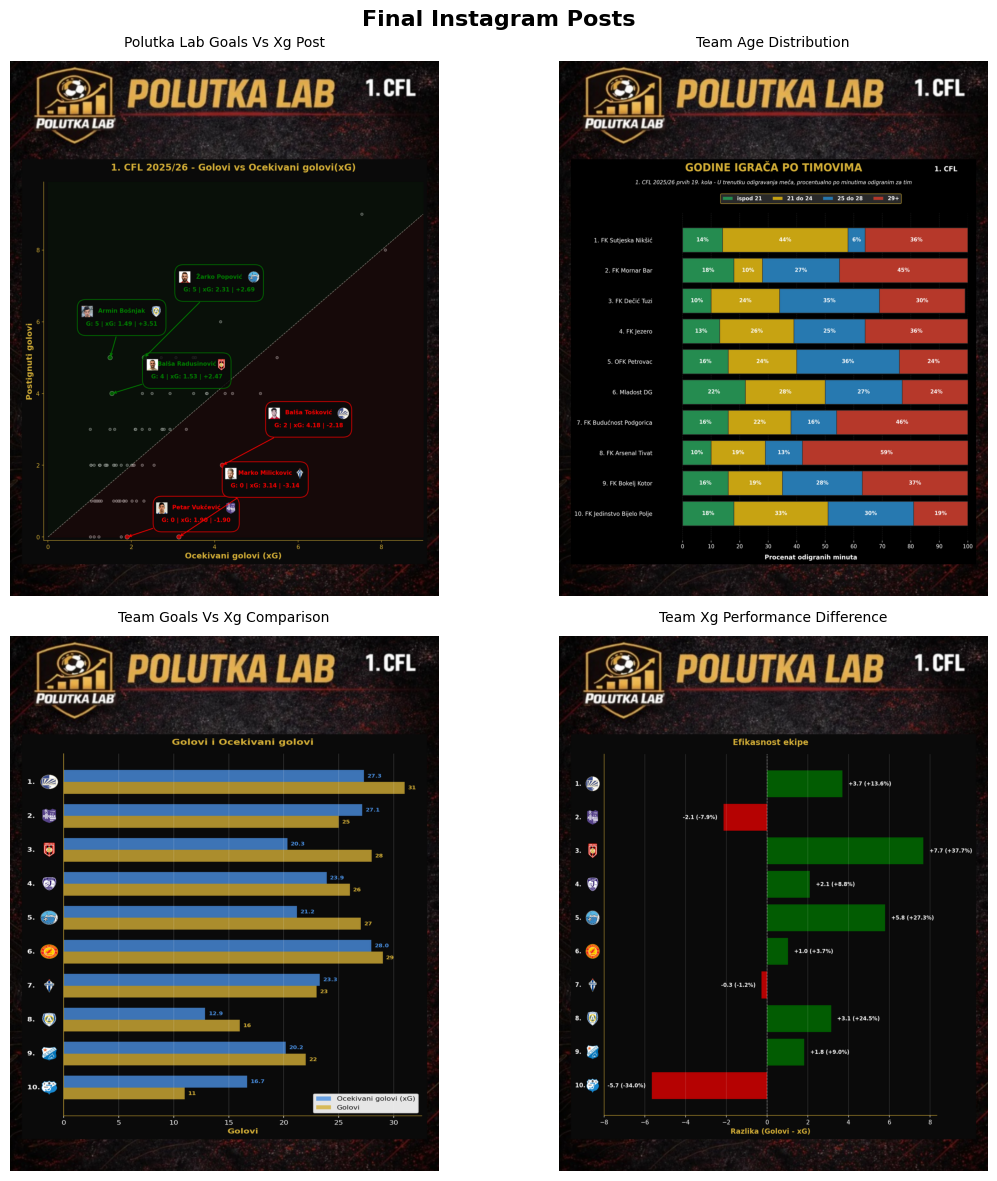

In [3]:
from IPython.display import display, Image as IPImage
import matplotlib.pyplot as plt

# Display all final posts (2x2 grid)
fig, axes = plt.subplots(2, 2, figsize=(12, 12))
fig.suptitle('Final Instagram Posts', fontsize=16, fontweight='bold')

for idx, figure_name in enumerate(FIGURES_TO_PROCESS):
    output_file = FINAL_POSTS_DIR / figure_name
    if output_file.exists():
        img = Image.open(output_file)
        row = idx // 2
        col = idx % 2
        axes[row, col].imshow(img)
        axes[row, col].axis('off')
        axes[row, col].set_title(figure_name.replace('.png', '').replace('_', ' ').title(), 
                                 fontsize=10, pad=10)
    else:
        row = idx // 2
        col = idx % 2
        axes[row, col].text(0.5, 0.5, f'File not found:\n{figure_name}', 
                           ha='center', va='center')
        axes[row, col].axis('off')

plt.tight_layout()
plt.show()

In [4]:
# Compose the Canva Venn diagram onto our Instagram template
venn_source = FIGURES_DIR / "venn_atacking.png"
venn_output = FINAL_POSTS_DIR / "venn_atacking_instagram.png"

if not venn_source.exists():
    raise FileNotFoundError(f"Could not find {venn_source}. Please place the Canva export there.")

background = Image.open(BACKGROUND_FILE)
if background.size != INSTAGRAM_SIZE:
    background = background.resize(INSTAGRAM_SIZE, Image.Resampling.LANCZOS)

safe_width = SAFE_ZONE['right'] - SAFE_ZONE['left']
safe_height = SAFE_ZONE['bottom'] - SAFE_ZONE['top']

venn_image = Image.open(venn_source)
if venn_image.mode != "RGBA":
    venn_image = venn_image.convert("RGBA")
venn_resized = venn_image.resize((safe_width, safe_height), Image.Resampling.LANCZOS)

position = (SAFE_ZONE['left'], SAFE_ZONE['top'])
background.paste(venn_resized, position, venn_resized)
background.save(venn_output, quality=95)

print(f"✓ Created Canva Venn post: {venn_output}")

✓ Created Canva Venn post: ..\outputs\final_posts\venn_atacking_instagram.png


In [5]:
# Compose the defensive Venn diagram onto our Instagram template
venn_defensive_source = FIGURES_DIR / "venn_defensive.png"
venn_defensive_output = FINAL_POSTS_DIR / "venn_defensive_instagram.png"

if not venn_defensive_source.exists():
    raise FileNotFoundError(f"Could not find {venn_defensive_source}.")

background = Image.open(BACKGROUND_FILE)
if background.size != INSTAGRAM_SIZE:
    background = background.resize(INSTAGRAM_SIZE, Image.Resampling.LANCZOS)

safe_width = SAFE_ZONE['right'] - SAFE_ZONE['left']
safe_height = SAFE_ZONE['bottom'] - SAFE_ZONE['top']

venn_defensive_image = Image.open(venn_defensive_source)
if venn_defensive_image.mode != "RGBA":
    venn_defensive_image = venn_defensive_image.convert("RGBA")
venn_defensive_resized = venn_defensive_image.resize((safe_width, safe_height), Image.Resampling.LANCZOS)

position = (SAFE_ZONE['left'], SAFE_ZONE['top'])
background.paste(venn_defensive_resized, position, venn_defensive_resized)
background.save(venn_defensive_output, quality=95)

print(f"✓ Created defensive Venn post: {venn_defensive_output}")

✓ Created defensive Venn post: ..\outputs\final_posts\venn_defensive_instagram.png


In [7]:
# Compose the substitute impact chart onto our Instagram template
substitute_impact_source = FIGURES_DIR / "substitute_impact.png"
substitute_impact_output = FINAL_POSTS_DIR / "substitute_impact_instagram.png"

if not substitute_impact_source.exists():
    raise FileNotFoundError(f"Could not find {substitute_impact_source}.")

background = Image.open(BACKGROUND_FILE)
if background.size != INSTAGRAM_SIZE:
    background = background.resize(INSTAGRAM_SIZE, Image.Resampling.LANCZOS)

safe_width = SAFE_ZONE['right'] - SAFE_ZONE['left']
safe_height = SAFE_ZONE['bottom'] - SAFE_ZONE['top']

substitute_impact_image = Image.open(substitute_impact_source)
if substitute_impact_image.mode != "RGBA":
    substitute_impact_image = substitute_impact_image.convert("RGBA")
substitute_impact_resized = substitute_impact_image.resize((safe_width, safe_height), Image.Resampling.LANCZOS)

position = (SAFE_ZONE['left'], SAFE_ZONE['top'])
background.paste(substitute_impact_resized, position, substitute_impact_resized)
background.save(substitute_impact_output, quality=95)

print(f"✓ Created substitute impact post: {substitute_impact_output}")

✓ Created substitute impact post: ..\outputs\final_posts\substitute_impact_instagram.png
